In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg  # για την προαιρετική ανάγνωση δικής σας εικόνας


## Άσκηση - Ανίχνευση ακμών με φίλτρο πρώτης διαφοράς

Οι **ακμές** μιας εικόνας είναι οι θέσεις όπου η φωτεινότητα μεταβάλλεται απότομα. Στη γλώσσα των σημάτων, μια απότομη μεταβολή σημαίνει μεγάλη τιμή **παραγώγου**! 

Το διακριτό ανάλογο της παραγώγου είναι η **κεντρική πρώτη διαφορά**, ένα σύστημα διακριτού χρόνου της μορφής:

$$ y[n] = \tfrac12\big(x[n+1] - x[n-1]\big) = \frac{1}{2}\sum_{k=-1}^{1} g_k\,x[n-k], \quad g=[-1,\,0,\,1] \tag{1}$$

Εφαρμοσμένο **κατά γραμμές**, το φίλτρο αυτό υπολογίζει την οριζόντια παράγωγο $g_x$ και αναδεικνύει τις **κατακόρυφες** ακμές, ενώ εφαρμοσμένο **κατά στήλες** δίνει την κατακόρυφη παράγωγο $g_y$ και αναδεικνύει τις **οριζόντιες** ακμές.

### i. Δημιουργία εικόνας

Χρησιμοποιούμε μια καθαρή συνθετική εικόνα με ευδιάκριτες ακμές, και επιπλέον μια ελαφρώς θορυβώδη εκδοχή για να δούμε ένα σημαντικό μειονέκτημα των διαφοριστών.

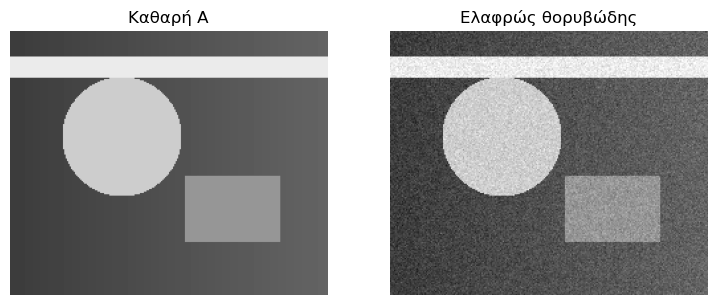

In [2]:
def make_test_image(M=200, N=240):
    """Δημιουργεί μια συνθετική grayscale εικόνα (τιμές 0-255) με ομαλό
    background, φωτεινό δίσκο, ορθογώνιο και λωρίδες (ακμές)."""
    yy, xx = np.mgrid[0:M, 0:N]
    A = 60.0 + 40.0*(xx/N)                       # ομαλή ράμπα φωτεινότητας
    A[(xx-0.35*N)**2 + (yy-0.40*M)**2 < 45**2] = 205   # φωτεινός δίσκος
    A[int(0.55*M):int(0.80*M), int(0.55*N):int(0.85*N)] = 150  # ορθογώνιο
    A[int(0.10*M):int(0.18*M), :] = 235          # οριζόντια λωρίδα
    return np.clip(A, 0, 255)

def add_gaussian_noise(A, sigma=25.0, seed=0):
    rng = np.random.default_rng(seed)
    return np.clip(A + rng.normal(0, sigma, A.shape), 0, 255)

A = make_test_image()
Bn = add_gaussian_noise(A, sigma=12)   # ελαφρύς θόρυβος

# --- Προαιρετικά: δική σας εικόνα ---
# A = mpimg.imread('./files/MyImage.tif').astype(float)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(A, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Καθαρή A'); ax[0].axis('off')
ax[1].imshow(Bn, cmap='gray', vmin=0, vmax=255); ax[1].set_title('Ελαφρώς θορυβώδης'); ax[1].axis('off')
plt.show()

### ii. Φιλτράρισμα κατά γραμμές

Η έξοδος μπορεί να είναι **αρνητική**, οπότε για την απεικόνιση χρησιμοποιούμε το **μέτρο** `|y|` (ή μετατόπιση κατά 128). Δείτε τον σκελετό κώδικα παρακάτω.

    M, N = A.shape
    Gx = np.zeros((M, N))
    for i in range(M):
        for j in range(1, N-1):
            x = A[i, j-1:j+2]         # τριάδα
            Gx[i, j] = #############  # Σχέση (1)

**Οριζόντια παράγωγος $g_x$ (κατά γραμμές) — αναδεικνύει κατακόρυφες ακμές**

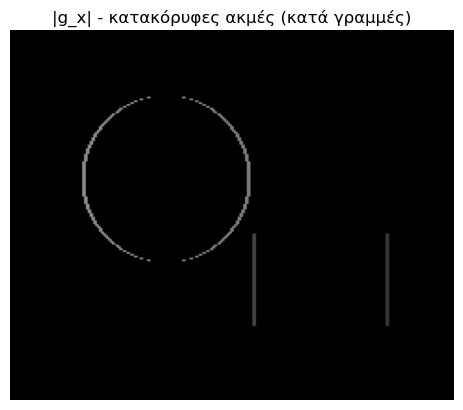

In [3]:
M, N = A.shape
Gx = np.zeros((M, N))

for i in range(M):
    for j in range(1, N-1):
        x = A[i, j-1:j+2]
        Gx[i, j] = 0.5*(x[2] - x[0])

C = np.clip(np.abs(Gx)*2, 0, 255).astype(np.uint8)  # x2 για ορατότητα
plt.figure()
plt.imshow(C, cmap=plt.get_cmap('gray'), vmin=0, vmax=255)
plt.title('|g_x| - κατακόρυφες ακμές (κατά γραμμές)')
plt.axis('off')
plt.show()

**Κατακόρυφη παράγωγος $g_y$ (κατά στήλες) — αναδεικνύει οριζόντιες ακμές**

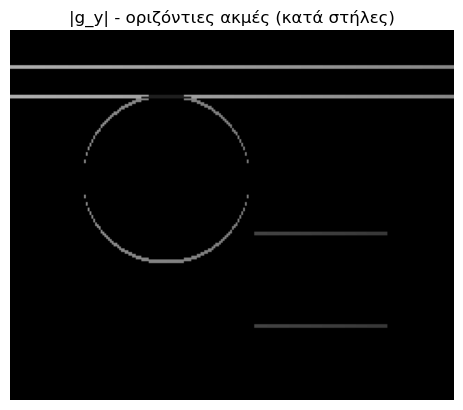

In [4]:
Gy = np.zeros((M, N))

for j in range(N):
    for i in range(1, M-1):
        x = A[i-1:i+2, j]
        Gy[i, j] = 0.5*(x[2] - x[0])

C = np.clip(np.abs(Gy)*2, 0, 255).astype(np.uint8)
plt.figure()
plt.imshow(C, cmap=plt.get_cmap('gray'), vmin=0, vmax=255)
plt.title('|g_y| - οριζόντιες ακμές (κατά στήλες)')
plt.axis('off')
plt.show()

### iii. Μέτρο κλίσης (gradient magnitude)

Συνδυάζοντας τις δύο κατευθύνσεις παίρνουμε το μέτρο της κλίσης, που αναδεικνύει **όλες** τις ακμές ανεξαρτήτως προσανατολισμού:

$$ |\nabla A|[m,n] = \sqrt{g_x^2[m,n] + g_y^2[m,n]} \tag{3}$$

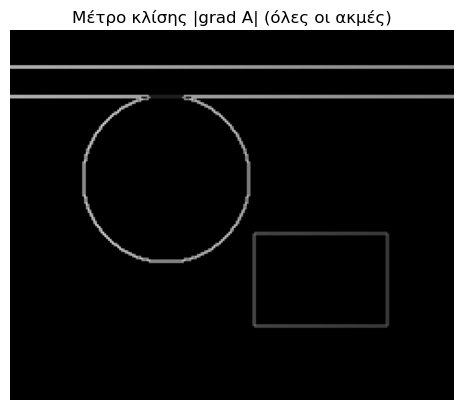

In [5]:
G = np.sqrt(Gx**2 + Gy**2)
C = np.clip(G*2, 0, 255).astype(np.uint8)
plt.figure()
plt.imshow(C, cmap=plt.get_cmap('gray'), vmin=0, vmax=255)
plt.title('Μέτρο κλίσης |grad A| (όλες οι ακμές)')
plt.axis('off')
plt.show()

### iv. Ευαισθησία στον θόρυβο

Επειδή ο διαφοριστής είναι **υψιπερατός**, ενισχύει τον θόρυβο υψηλών συχνοτήτων. Εφαρμόζουμε το ίδιο φίλτρο στη θορυβώδη εικόνα `Bn`:

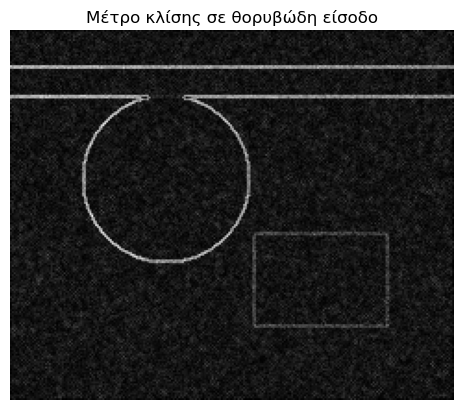

In [6]:
Gx_n = np.zeros((M, N)); Gy_n = np.zeros((M, N))
for i in range(M):
    for j in range(1, N-1):
        Gx_n[i, j] = 0.5*(Bn[i, j+1] - Bn[i, j-1])
for j in range(N):
    for i in range(1, M-1):
        Gy_n[i, j] = 0.5*(Bn[i+1, j] - Bn[i-1, j])

C = np.clip(np.sqrt(Gx_n**2 + Gy_n**2)*2, 0, 255).astype(np.uint8)
plt.figure()
plt.imshow(C, cmap=plt.get_cmap('gray'), vmin=0, vmax=255)
plt.title('Μέτρο κλίσης σε θορυβώδη είσοδο')
plt.axis('off')
plt.show()

### Παρατηρήσεις

Το φίλτρο πρώτης διαφοράς μηδενίζει τις ομοιόμορφες περιοχές και «ανάβει» μόνο στις ακμές. Η κατευθυντικότητα είναι εμφανής: το πέρασμα κατά γραμμές βρίσκει τις κατακόρυφες ακμές (π.χ. τις πλευρές του δίσκου και του ορθογωνίου), ενώ το πέρασμα κατά στήλες βρίσκει τις οριζόντιες (π.χ. τη λωρίδα). Το μέτρο της κλίσης τις ενοποιεί. 

Στη θορυβώδη εικόνα φαίνεται το βασικό μειονέκτημα: ο διαφοριστής **ενισχύει τον θόρυβο**, γι' αυτό στην πράξη οι τελεστές Sobel/Prewitt συνδυάζουν τη διαφορά προς μία κατεύθυνση με μια εξομάλυνση $[1,2,1]$ προς την **κάθετη** - δηλαδή «πρώτα φιλτράρω, μετά παραγωγίζω».

---
---